In [15]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as sco
import scipy.stats as stats

In [16]:
# 1. Define assets and timeframe
tickers = ['^GSPC', '^HSI', 'AGG']
start_date = '2016-01-01'
end_date = '2026-03-01'

In [17]:
# 2. Fetch and clean data
print("Fetching data from Yahoo Finance...")
downloaded = yf.download(tickers, start=start_date, end=end_date, progress=False)
if isinstance(downloaded.columns, pd.MultiIndex):
    price_level = downloaded.columns.get_level_values(0)
    raw_data = downloaded['Adj Close'] if 'Adj Close' in price_level else downloaded['Close']
else:
    raw_data = downloaded['Adj Close'] if 'Adj Close' in downloaded.columns else downloaded['Close']
clean_data = raw_data.ffill().dropna()
clean_data = clean_data[['^GSPC', '^HSI', 'AGG']]
display(clean_data.head())

Fetching data from Yahoo Finance...


Ticker,^GSPC,^HSI,AGG
Date,,,
2016-01-04,2012.660034,21327.119141,81.585670
2016-01-05,2016.709961,21188.720703,81.623505
2016-01-06,1990.260010,20980.810547,81.933334
2016-01-07,1943.089966,20333.339844,81.925728
2016-01-08,1922.030029,20453.710938,82.107086


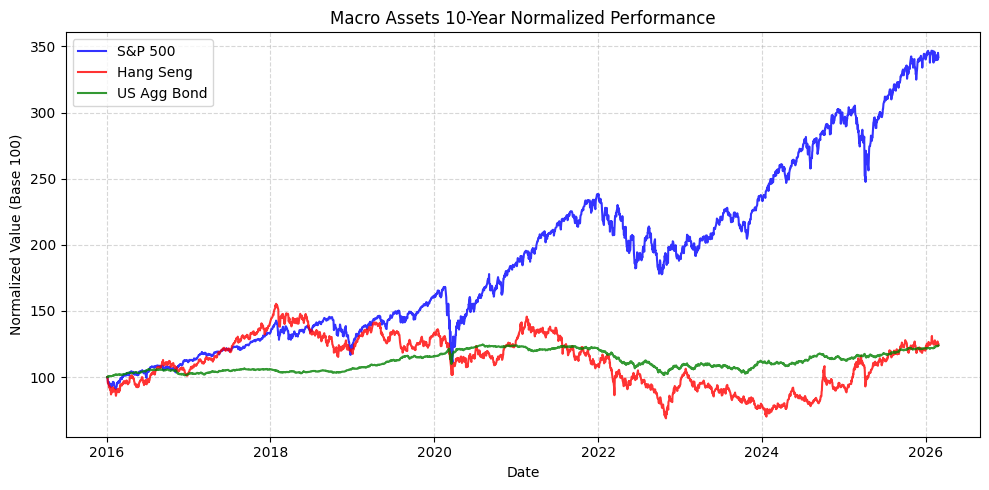

In [18]:
# 3. Plot normalized performance
plt.figure(figsize=(10, 5))
normalized_data = (clean_data / clean_data.iloc[0]) * 100
colors = {'^GSPC': 'blue', '^HSI': 'red', 'AGG': 'green'}
labels = {'^GSPC': 'S&P 500', '^HSI': 'Hang Seng', 'AGG': 'US Agg Bond'}
for ticker in tickers:
    plt.plot(normalized_data[ticker], label=labels[ticker], color=colors[ticker], alpha=0.8)

plt.title('Macro Assets 10-Year Normalized Performance')
plt.ylabel('Normalized Value (Base 100)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
# 4. Calculate daily returns
returns = clean_data.pct_change().dropna()

# 5. Calculate annualized metrics (assuming 252 trading days in a year)
trading_days = 252
annual_returns = returns.mean() * trading_days
annual_cov_matrix = returns.cov() * trading_days

print("--- Annualized Expected Returns ---")
display(pd.DataFrame(annual_returns, columns=['Expected Return']))
print("\n--- Annualized Covariance Matrix ---")
display(annual_cov_matrix)

--- Annualized Expected Returns ---


,Expected Return
Ticker,
^GSPC,0.134203
^HSI,0.044491
AGG,0.022014



--- Annualized Covariance Matrix ---


Ticker,^GSPC,^HSI,AGG
Ticker,,,
^GSPC,0.031742,0.006678,0.001028
^HSI,0.006678,0.046140,-0.000030
AGG,0.001028,-0.000030,0.002781


Running Monte Carlo Simulation for 10,000 portfolios...


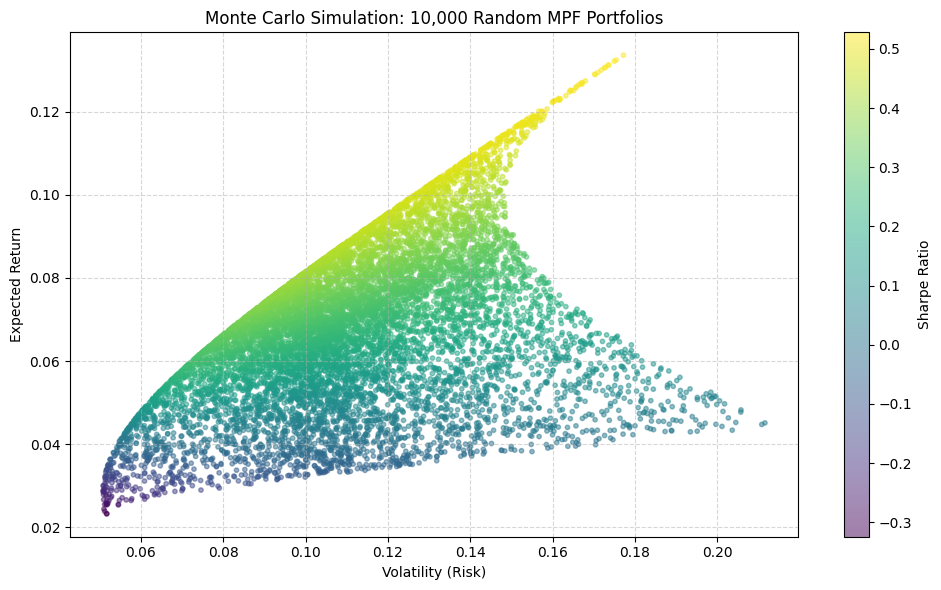

In [20]:
# 6. Monte Carlo Simulation
num_portfolios = 10000
risk_free_rate = 0.04
results = np.zeros((3, num_portfolios))
all_weights = []

print("Running Monte Carlo Simulation for 10,000 portfolios...")

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    all_weights.append(weights)
    port_return = np.sum(weights * annual_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(annual_cov_matrix, weights)))
    results[0,i] = port_return
    results[1,i] = port_volatility
    results[2,i] = (port_return - risk_free_rate) / port_volatility
results_df = pd.DataFrame(results.T, columns=['Return', 'Volatility', 'Sharpe'])

# 7. Plot the simulated portfolios
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Volatility'], results_df['Return'], 
            c=results_df['Sharpe'], cmap='viridis', marker='o', s=10, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Monte Carlo Simulation: 10,000 Random MPF Portfolios')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
# 8. Define Objective Functions for Optimization
def calc_portfolio_perf(weights, returns, cov_matrix, rf_rate):
    p_ret = np.sum(weights * returns)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return p_ret, p_vol

def neg_sharpe(weights, returns, cov_matrix, rf_rate):
    p_ret, p_vol = calc_portfolio_perf(weights, returns, cov_matrix, rf_rate)
    return -(p_ret - rf_rate) / p_vol

def get_volatility(weights, returns, cov_matrix, rf_rate):
    return calc_portfolio_perf(weights, returns, cov_matrix, rf_rate)[1]

# 9. Constraints and Bounds
num_assets = len(tickers)
args = (annual_returns, annual_cov_matrix, risk_free_rate)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.0, 1.0) for asset in range(num_assets))
initial_guess = num_assets * [1. / num_assets]

# 10. Run Optimizations
opt_sharpe = sco.minimize(neg_sharpe, initial_guess, args=args,
                          method='SLSQP', bounds=bounds, constraints=constraints)

opt_min_vol = sco.minimize(get_volatility, initial_guess, args=args,
                           method='SLSQP', bounds=bounds, constraints=constraints)

# 11. Display Final Results
print("=" * 50)
print("OPTIMAL PORTFOLIO 1: Maximum Sharpe Ratio (Aggressive)")
print("-" * 50)
sharpe_weights = pd.DataFrame(opt_sharpe.x, index=tickers, columns=['Allocation (%)'])
sharpe_weights['Allocation (%)'] = (sharpe_weights['Allocation (%)'] * 100).round(2)
display(sharpe_weights)
print("\n" + "=" * 50)
print("OPTIMAL PORTFOLIO 2: Global Minimum Volatility (Conservative)")
print("-" * 50)
min_vol_weights = pd.DataFrame(opt_min_vol.x, index=tickers, columns=['Allocation (%)'])
min_vol_weights['Allocation (%)'] = (min_vol_weights['Allocation (%)'] * 100).round(2)
display(min_vol_weights)

OPTIMAL PORTFOLIO 1: Maximum Sharpe Ratio (Aggressive)
--------------------------------------------------


,Allocation (%)
^GSPC,100.0
^HSI,0.0
AGG,0.0



OPTIMAL PORTFOLIO 2: Global Minimum Volatility (Conservative)
--------------------------------------------------


,Allocation (%)
^GSPC,4.12
^HSI,5.03
AGG,90.85


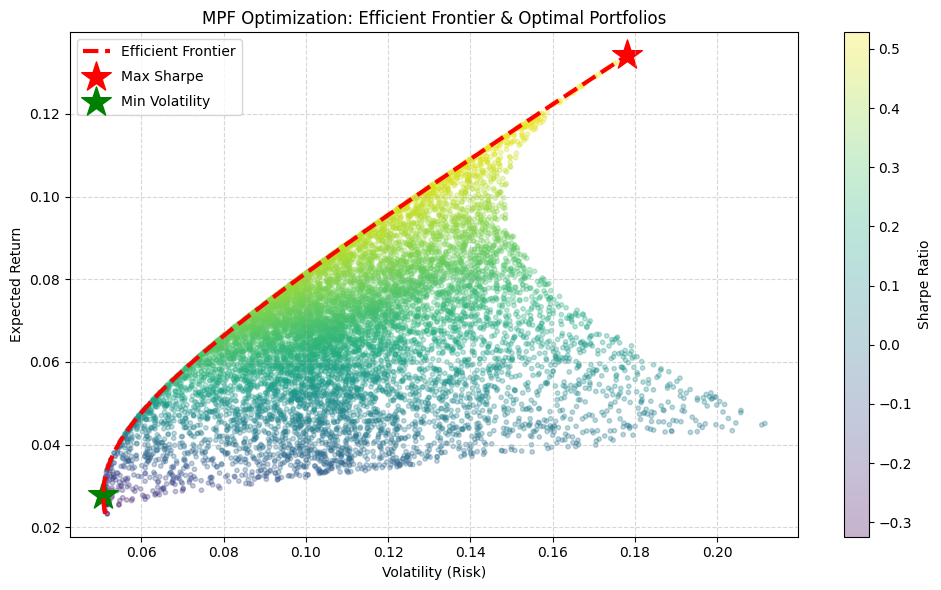

In [22]:
# 12. Plot the final Line
target_returns = np.linspace(results_df['Return'].min(), results_df['Return'].max(), 50)
efficient_vols = []

for tr in target_returns:
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: calc_portfolio_perf(x, annual_returns, annual_cov_matrix, risk_free_rate)[0] - tr})
    res = sco.minimize(get_volatility, initial_guess, args=args, method='SLSQP', bounds=bounds, constraints=cons)
    efficient_vols.append(res.fun)

plt.figure(figsize=(10, 6))

plt.scatter(results_df['Volatility'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

plt.plot(efficient_vols, target_returns, 'r--', linewidth=3, label='Efficient Frontier')

max_sharpe_ret = calc_portfolio_perf(opt_sharpe.x, annual_returns, annual_cov_matrix, risk_free_rate)[0]
max_sharpe_vol = calc_portfolio_perf(opt_sharpe.x, annual_returns, annual_cov_matrix, risk_free_rate)[1]
plt.scatter(max_sharpe_vol, max_sharpe_ret, marker='*', color='r', s=500, label='Max Sharpe')

min_vol_ret = calc_portfolio_perf(opt_min_vol.x, annual_returns, annual_cov_matrix, risk_free_rate)[0]
min_vol_vol = calc_portfolio_perf(opt_min_vol.x, annual_returns, annual_cov_matrix, risk_free_rate)[1]
plt.scatter(min_vol_vol, min_vol_ret, marker='*', color='g', s=500, label='Min Volatility')

plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('MPF Optimization: Efficient Frontier & Optimal Portfolios')
plt.legend(labelspacing=0.8)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [30]:
# 13. Goal-Based Investing
target_input = input("Enter your target annualized return (e.g., 0.06 for 6%): ")

try:
    target_return = float(target_input)
    min_ret = annual_returns.min()
    max_ret = annual_returns.max()
    
    if target_return < min_ret or target_return > max_ret:
        print(f"\nWarning: Target {target_return*100:.2f}% is mathematically impossible based on historical data.")
        print(f"Please enter a value between {min_ret*100:.2f}% and {max_ret*100:.2f}%.")
    else:
        target_constraints = (
            {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: calc_portfolio_perf(x, annual_returns, annual_cov_matrix, risk_free_rate)[0] - target_return}
        )
        
        opt_target = sco.minimize(get_volatility, initial_guess, args=args,
                                  method='SLSQP', bounds=bounds, constraints=target_constraints)
        
        minimized_vol = opt_target.fun
        
        print("\n" + "=" * 60)
        print(f"CUSTOM PORTFOLIO: Minimum Risk for {target_return*100:.2f}% Target Return")
        print("-" * 60)
        
        custom_weights = pd.DataFrame(opt_target.x, index=tickers, columns=['Allocation (%)'])
        custom_weights['Allocation (%)'] = (custom_weights['Allocation (%)'] * 100).round(2)
        display(custom_weights)
        
        print("\nRISK ANALYSIS & STRESS TEST")
        print("-" * 60)
        print(f"Expected Annual Volatility (Risk): {minimized_vol*100:.2f}%")
        
        worst_case = target_return - (1.645 * minimized_vol)
        
        print(f"\nIf you aim for {target_return*100:.2f}% return, you must accept the underlying risk.")
        print("In a severe market downturn (95% confidence worst-case year),")
        if worst_case < 0:
            print(f"your MPF portfolio could drop by {abs(worst_case)*100:.2f}%.")
        else:
            print(f"your MPF portfolio return could fall to {worst_case*100:.2f}%.")
        print("=" * 60)
        
except ValueError:
    print("Invalid input. Please enter a numerical value like 0.06")


CUSTOM PORTFOLIO: Minimum Risk for 13.42% Target Return
------------------------------------------------------------


,Allocation (%)
^GSPC,100.0
^HSI,0.0
AGG,0.0



RISK ANALYSIS & STRESS TEST
------------------------------------------------------------
Expected Annual Volatility (Risk): 17.82%

If you aim for 13.42% return, you must accept the underlying risk.
In a severe market downturn (95% confidence worst-case year),
your MPF portfolio could drop by 15.89%.
